In [33]:
# ---------------------------
# 1) Load the dataset
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [34]:
# ==============================
# 1) LOAD DATA
# ==============================

df = pd.read_csv("weatherData.csv")
df.columns = df.columns.astype(str).str.strip()   # remove hidden spaces
print("Loaded:", df.shape)
print(df.head())

Loaded: (142371, 21)
   location_id      date  weather_code (wmo code)  temperature_2m_max (°C)  \
0            0  1/1/2010                        1                     30.1   
1            0  1/2/2010                       51                     30.1   
2            0  1/3/2010                       51                     29.6   
3            0  1/4/2010                        2                     28.9   
4            0  1/5/2010                        1                     28.1   

   temperature_2m_min (°C)  temperature_2m_mean (°C)  \
0                     22.6                      26.0   
1                     23.7                      26.3   
2                     23.1                      26.0   
3                     23.1                      25.7   
4                     21.3                      24.6   

   apparent_temperature_max (°C)  apparent_temperature_min (°C)  \
0                           34.5                           25.0   
1                           33.9       

In [35]:
print("Loaded dataset!")
print("Shape:", df.shape)
print("\n--- First 5 rows ---")
print(df.head())

Loaded dataset!
Shape: (142371, 21)

--- First 5 rows ---
   location_id      date  weather_code (wmo code)  temperature_2m_max (°C)  \
0            0  1/1/2010                        1                     30.1   
1            0  1/2/2010                       51                     30.1   
2            0  1/3/2010                       51                     29.6   
3            0  1/4/2010                        2                     28.9   
4            0  1/5/2010                        1                     28.1   

   temperature_2m_min (°C)  temperature_2m_mean (°C)  \
0                     22.6                      26.0   
1                     23.7                      26.3   
2                     23.1                      26.0   
3                     23.1                      25.7   
4                     21.3                      24.6   

   apparent_temperature_max (°C)  apparent_temperature_min (°C)  \
0                           34.5                           25.0   
1 

In [36]:
# ---------------------------
# 2) Basic info + duplicates
# ---------------------------
print("\n--- Info ---")
print(df.info())

dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)


--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142371 entries, 0 to 142370
Data columns (total 21 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   location_id                      142371 non-null  int64  
 1   date                             142371 non-null  object 
 2   weather_code (wmo code)          142371 non-null  int64  
 3   temperature_2m_max (°C)          142371 non-null  float64
 4   temperature_2m_min (°C)          142371 non-null  float64
 5   temperature_2m_mean (°C)         142371 non-null  float64
 6   apparent_temperature_max (°C)    142371 non-null  float64
 7   apparent_temperature_min (°C)    142371 non-null  float64
 8   apparent_temperature_mean (°C)   142371 non-null  float64
 9   daylight_duration (s)            142371 non-null  float64
 10  sunshine_duration (s)            142371 non-null  float64
 11  precipitation_sum (mm)           142371 non-null  f

In [37]:
# Clean column names
df.columns = df.columns.astype(str).str.strip()
print("Columns:", df.columns.tolist())

Columns: ['location_id', 'date', 'weather_code (wmo code)', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'temperature_2m_mean (°C)', 'apparent_temperature_max (°C)', 'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)', 'daylight_duration (s)', 'sunshine_duration (s)', 'precipitation_sum (mm)', 'rain_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)', 'wind_gusts_10m_max (km/h)', 'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)', 'sunrise', 'sunset']


In [38]:
# ---------------------------
# 3) Clean column names (optional but recommended)
# ---------------------------
df.columns = (
    df.columns
      .astype(str)
      .str.strip()
      .str.replace(r"\s+", "_", regex=True)
      .str.replace(r"[^\w_]", "", regex=True)
)

print("\n Cleaned column names:")
print(df.columns.tolist())


 Cleaned column names:
['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']


In [39]:
# ---------------------------
# 4) Missing values summary
# ---------------------------
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing,
    "missing_%": missing_pct
}).query("missing_count > 0")

print("\n--- Missing Values Summary (only > 0) ---")
print(missing_summary if not missing_summary.empty else "No missing values ")


--- Missing Values Summary (only > 0) ---
No missing values 


In [40]:
# Plot missing values (top 20)
if not missing_summary.empty:
    top = missing_summary.head(20)
    plt.figure(figsize=(10, 5))
    plt.bar(top.index.astype(str), top["missing_count"])
    plt.xticks(rotation=60, ha="right")
    plt.title("Missing Values Count (Top 20 columns)")
    plt.tight_layout()
    plt.show()

In [41]:
import pandas as pd

# Clean column names (removes hidden spaces)
df.columns = df.columns.astype(str).str.strip()

print("Columns:", df.columns.tolist())

# Auto-detect a date/time column
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])]

DATE_COL = None
best_ratio = 0

for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors="coerce")
    ratio = parsed.notna().mean()
    if ratio > best_ratio:
        best_ratio = ratio
        DATE_COL = c

if DATE_COL is None or best_ratio < 0.5:
    raise ValueError(f"No reliable date column found. Date-like columns tried: {date_like_cols}")

print("Using date column:", DATE_COL, " (parse success:", round(best_ratio, 2), ")")

Columns: ['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']
Using date column: date  (parse success: 1.0 )


In [42]:
# ---------------------------
# 6) Identify numeric & categorical columns
# ---------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print("\nNumeric columns:", numeric_cols)
print("Categorical/Other columns:", cat_cols)


Numeric columns: ['location_id', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm']
Categorical/Other columns: ['date', 'sunrise', 'sunset']


In [43]:
# ---------------------------
# 7) Descriptive statistics
# ---------------------------
print("\n--- Numeric describe() ---")
if numeric_cols:
    print(df[numeric_cols].describe().T)
else:
    print("No numeric columns found.")

print("\n--- Categorical describe() ---")
if cat_cols:
    print(df[cat_cols].describe().T)
else:
    print("No categorical columns found.")


--- Numeric describe() ---
                                  count          mean          std       min  \
location_id                    142371.0     13.000000     7.788908      0.00   
weather_code_wmo_code          142371.0     44.891586    22.840879      0.00   
temperature_2m_max_C           142371.0     29.295854     3.352774     14.10   
temperature_2m_min_C           142371.0     23.120601     3.165760      5.30   
temperature_2m_mean_C          142371.0     25.730017     2.954064     12.10   
apparent_temperature_max_C     142371.0     33.560477     4.183799     11.00   
apparent_temperature_min_C     142371.0     26.362139     4.196010      2.00   
apparent_temperature_mean_C    142371.0     29.234477     3.837440      9.50   
daylight_duration_s            142371.0  43645.975220  1099.470021  41610.71   
sunshine_duration_s            142371.0  34676.319743  8910.054804      0.00   
precipitation_sum_mm           142371.0      5.442717    10.286371      0.00   
rain_sum_mm 

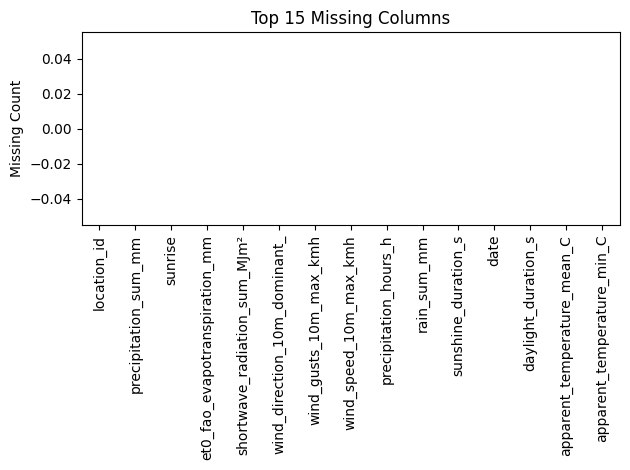

In [44]:
# Missing values bar (top 15)
na = df.isna().sum().sort_values(ascending=False).head(15)
plt.figure()
na.plot(kind="bar")
plt.title("Top 15 Missing Columns")
plt.ylabel("Missing Count")
plt.tight_layout()
plt.show()

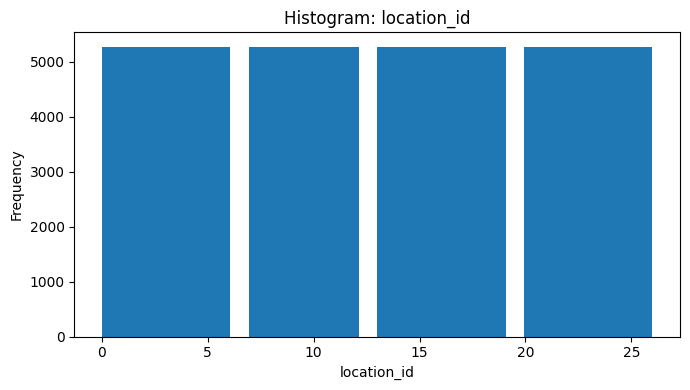

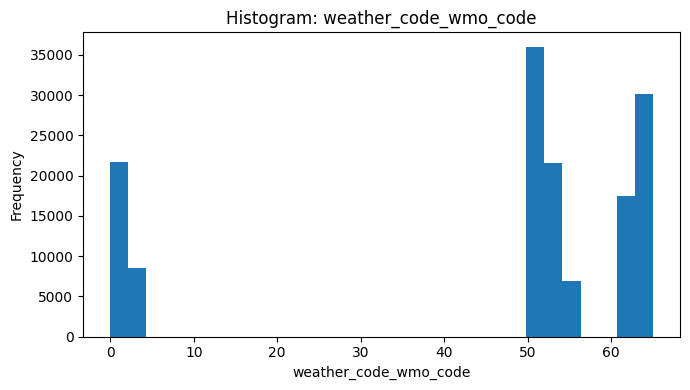

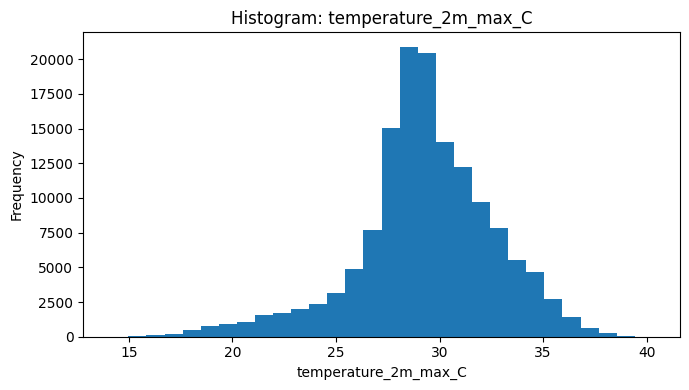

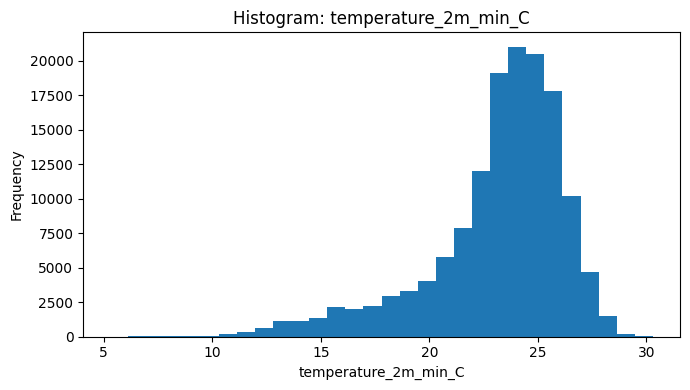

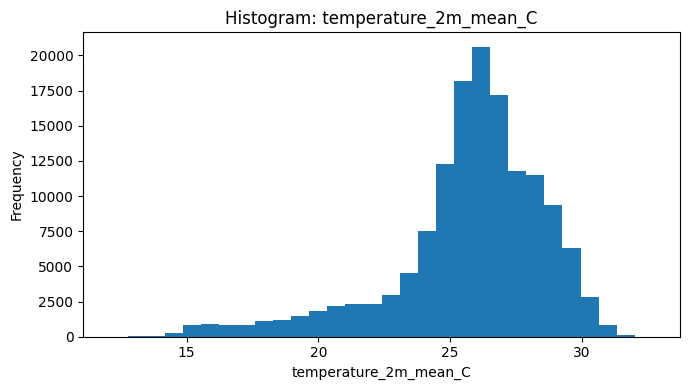

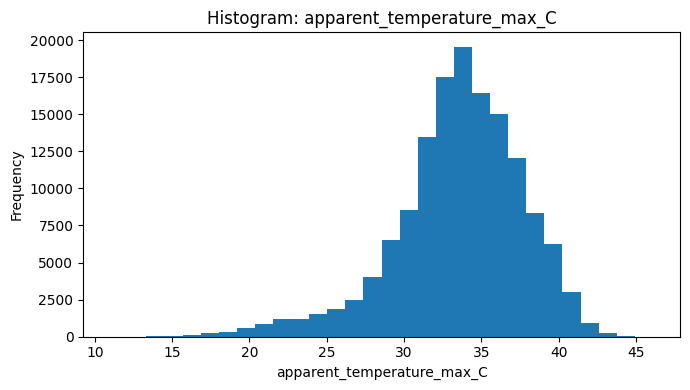

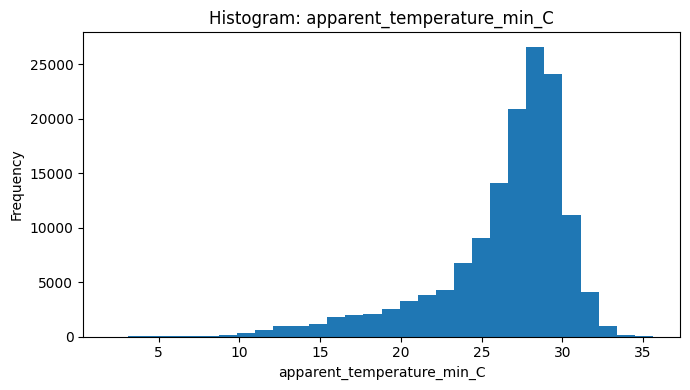

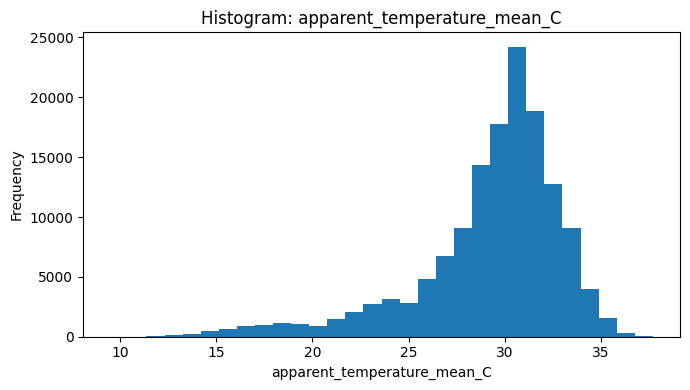

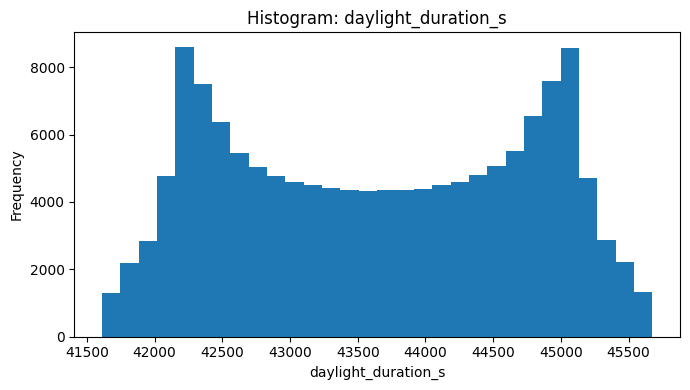

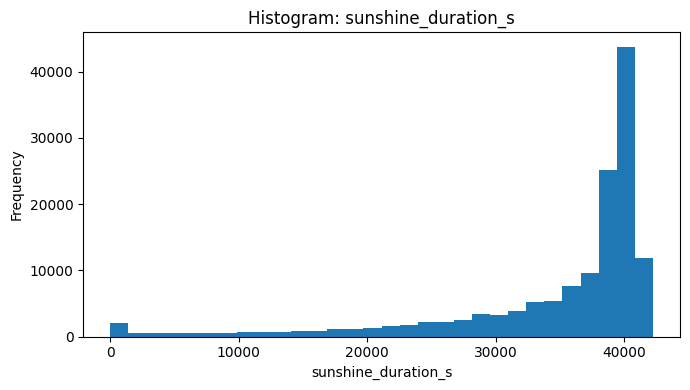

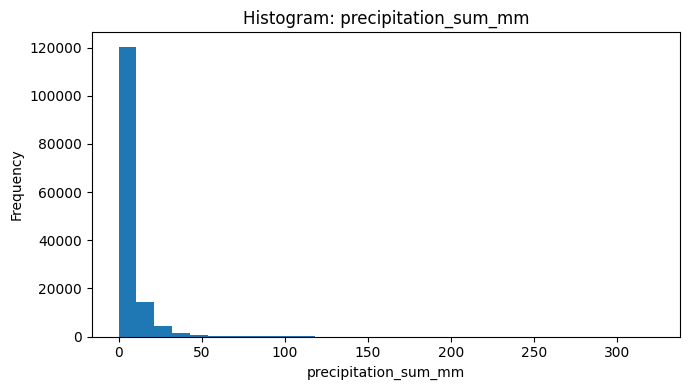

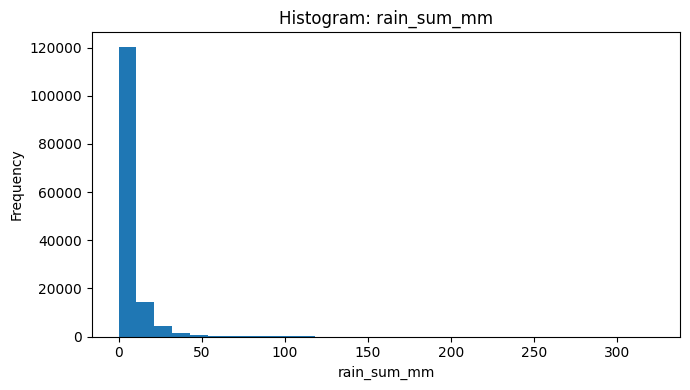

In [45]:
# ---------------------------
# 8) Univariate Visualizations
# ---------------------------

# 8A) Histograms for numeric columns (top 12 to avoid overload)
if numeric_cols:
    cols_to_plot = numeric_cols[:12]
    for c in cols_to_plot:
        plt.figure(figsize=(7, 4))
        plt.hist(df[c].dropna(), bins=30)
        plt.title(f"Histogram: {c}")
        plt.xlabel(c)
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

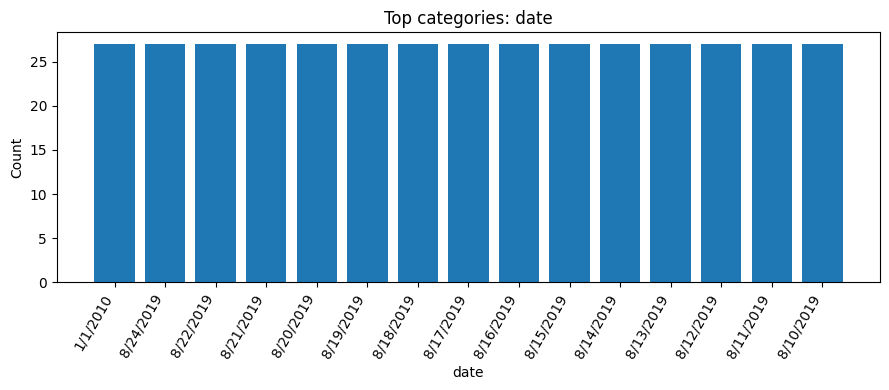

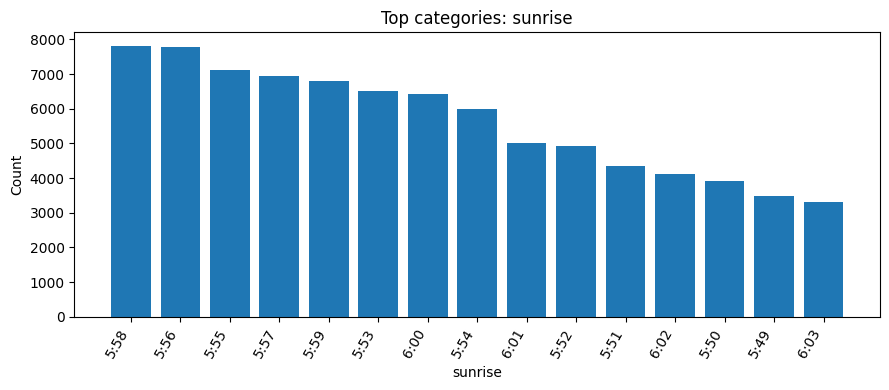

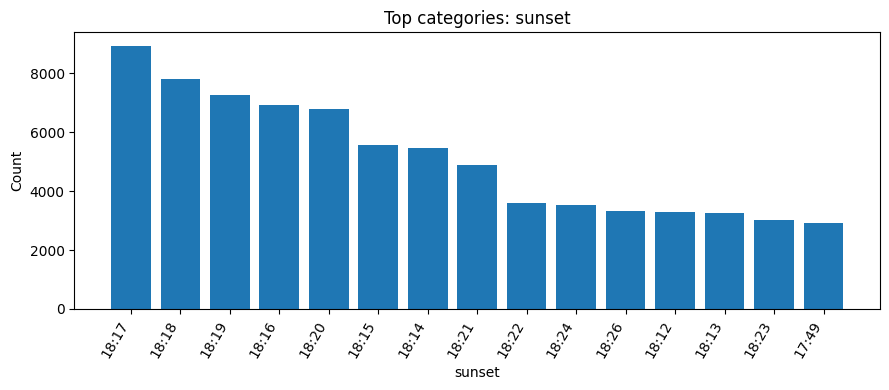

In [46]:
# 8B) Bar chart for categorical columns (top 8)
if cat_cols:
    cols_to_plot = cat_cols[:8]
    for c in cols_to_plot:
        vc = df[c].astype(str).value_counts().head(15)  # top 15 categories
        plt.figure(figsize=(9, 4))
        plt.bar(vc.index, vc.values)
        plt.xticks(rotation=60, ha="right")
        plt.title(f"Top categories: {c}")
        plt.xlabel(c)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

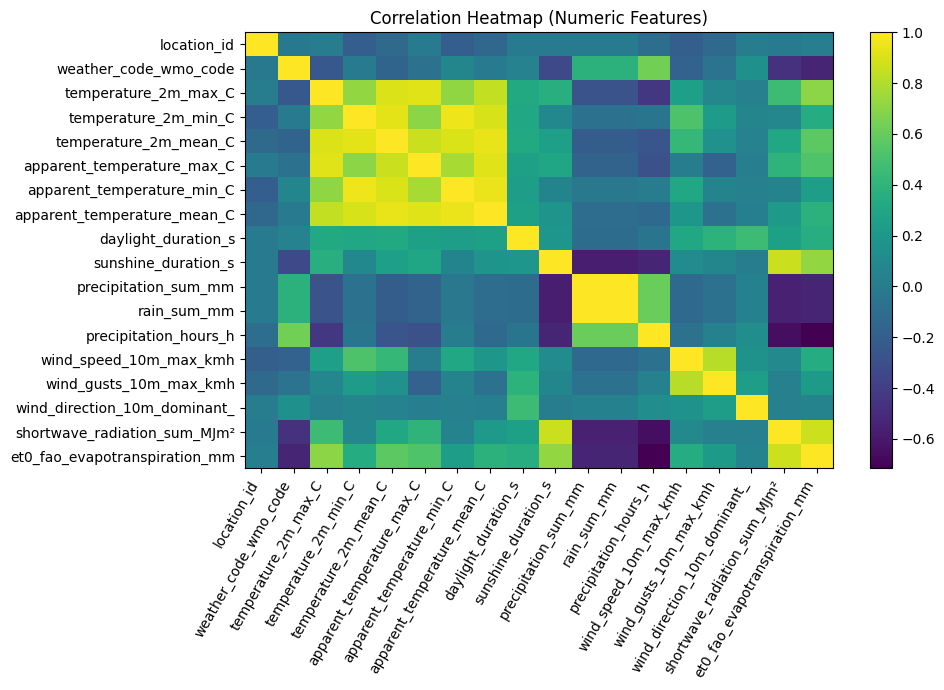


--- Top 10 Positive Correlations ---
precipitation_sum_mm        rain_sum_mm                    1.000000
temperature_2m_min_C        apparent_temperature_min_C     0.959653
apparent_temperature_min_C  apparent_temperature_mean_C    0.950551
temperature_2m_mean_C       apparent_temperature_mean_C    0.944824
temperature_2m_min_C        temperature_2m_mean_C          0.931778
temperature_2m_max_C        apparent_temperature_max_C     0.917679
apparent_temperature_max_C  apparent_temperature_mean_C    0.917584
temperature_2m_max_C        temperature_2m_mean_C          0.909368
temperature_2m_mean_C       apparent_temperature_min_C     0.905349
temperature_2m_min_C        apparent_temperature_mean_C    0.894691
dtype: float64

--- Top 10 Negative Correlations ---
precipitation_sum_mm   et0_fao_evapotranspiration_mm   -0.537398
rain_sum_mm            et0_fao_evapotranspiration_mm   -0.537398
weather_code_wmo_code  et0_fao_evapotranspiration_mm   -0.538329
sunshine_duration_s    precipitati

In [47]:
# ---------------------------
# 9) Correlation heatmap (without seaborn)
# ---------------------------
if len(numeric_cols) >= 2:
    corr = df[numeric_cols].corr()

    plt.figure(figsize=(10, 7))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

    # Show top correlated pairs
    corr_pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .sort_values(ascending=False)
    )
    print("\n--- Top 10 Positive Correlations ---")
    print(corr_pairs.head(10))

    print("\n--- Top 10 Negative Correlations ---")
    print(corr_pairs.tail(10))

In [48]:
# ==============================
# 2) AUTO-DETECT IMPORTANT COLUMNS
# ==============================
# ---- Detect date/time column ----
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])]
DATE_COL = None
best_ratio = 0

for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors="coerce")
    ratio = parsed.notna().mean()
    if ratio > best_ratio:
        best_ratio = ratio
        DATE_COL = c

if DATE_COL is None:
    raise ValueError(f"No date-like column found. Date-like candidates: {date_like_cols}")

df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
print(f"Using DATE_COL = {DATE_COL} (parse success {best_ratio:.2f})")

# ---- Detect location column ----
LOC_CANDIDATES = ["location_id", "location", "city", "station", "station_id", "district"]
LOC_COL = next((c for c in LOC_CANDIDATES if c in df.columns), None)
if LOC_COL is None:
    raise ValueError(f"No location column found. Tried {LOC_CANDIDATES}")

df[LOC_COL] = df[LOC_COL].astype(str)
print(f"Using LOC_COL = {LOC_COL}")

# ---- Detect targets ----
def pick_col_by_keywords(keywords, fallback_contains=None):
    cols = df.columns.tolist()
    candidates = []
    for c in cols:
        cl = c.lower()
        if any(k in cl for k in keywords):
            candidates.append(c)
    if not candidates and fallback_contains:
        candidates = [c for c in cols if fallback_contains in c.lower()]
    return candidates

# Temperature mean candidates
temp_candidates = pick_col_by_keywords(["temperature_2m_mean", "temp_mean", "temperature_mean", "temperature"])

# Rainfall candidates (prefer precipitation_sum_mm, rain_sum_mm)
rain_candidates = pick_col_by_keywords(["precipitation_sum", "rain_sum", "rainfall", "precipitation"])

# Sunshine candidates (often sunshine_duration_s or sunshine)
sun_candidates = pick_col_by_keywords(["sunshine_duration", "sunshine"])

print("\n--- Target Candidates ---")
print("Temperature:", temp_candidates[:10])
print("Rainfall   :", rain_candidates[:10])
print("Sunshine   :", sun_candidates[:10])

if not temp_candidates or not rain_candidates or not sun_candidates:
    raise ValueError(
        "Could not detect one or more targets.\n"
        f"Temp candidates: {temp_candidates}\nRain candidates: {rain_candidates}\nSun candidates: {sun_candidates}\n"
        "Check your column names."
    )

TEMP_COL = temp_candidates[0]
RAIN_COL = rain_candidates[0]
SUN_COL  = sun_candidates[0]

print(f"\nUsing TEMP_COL={TEMP_COL}")
print(f"Using RAIN_COL={RAIN_COL}")
print(f"Using SUN_COL={SUN_COL}")

Using DATE_COL = date (parse success 1.00)
Using LOC_COL = location_id

--- Target Candidates ---
Temperature: ['temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C']
Rainfall   : ['precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h']
Sunshine   : ['sunshine_duration_s']

Using TEMP_COL=temperature_2m_max_C
Using RAIN_COL=precipitation_sum_mm
Using SUN_COL=sunshine_duration_s


In [49]:
# ==============================
# 3) BASIC EDA
# ==============================
print("\nData Info:")
print(df[[DATE_COL, LOC_COL, TEMP_COL, RAIN_COL, SUN_COL]].info())

print("\nMissing values (top 20):")
print(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDescribe Targets:")
print(df[[TEMP_COL, RAIN_COL, SUN_COL]].describe())


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142371 entries, 0 to 142370
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   date                  142371 non-null  datetime64[ns]
 1   location_id           142371 non-null  object        
 2   temperature_2m_max_C  142371 non-null  float64       
 3   precipitation_sum_mm  142371 non-null  float64       
 4   sunshine_duration_s   142371 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 4.9+ MB
None

Missing values (top 20):
location_id                      0
precipitation_sum_mm             0
sunrise                          0
et0_fao_evapotranspiration_mm    0
shortwave_radiation_sum_MJm²     0
wind_direction_10m_dominant_     0
wind_gusts_10m_max_kmh           0
wind_speed_10m_max_kmh           0
precipitation_hours_h            0
rain_sum_mm                      0
sunshine_dura

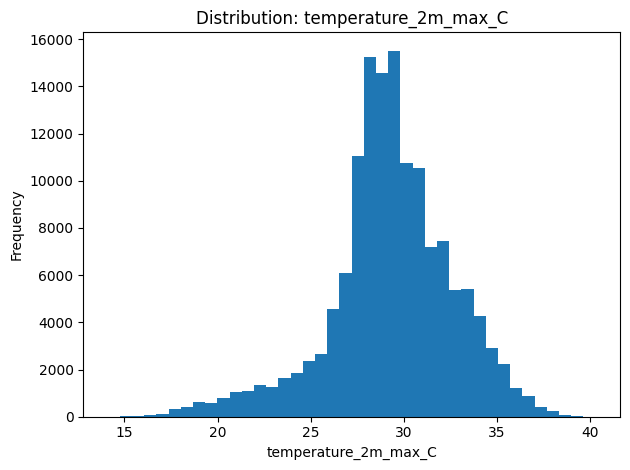

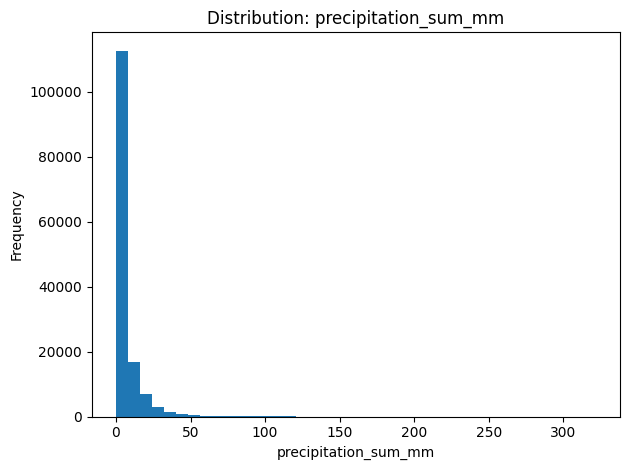

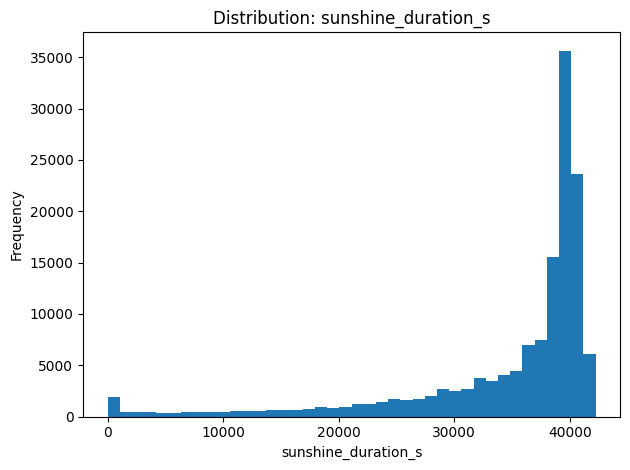

In [50]:
targets_to_plot = [TEMP_COL, RAIN_COL, SUN_COL]
for col in targets_to_plot:
    plt.figure()
    df[col].dropna().plot(kind="hist", bins=40)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

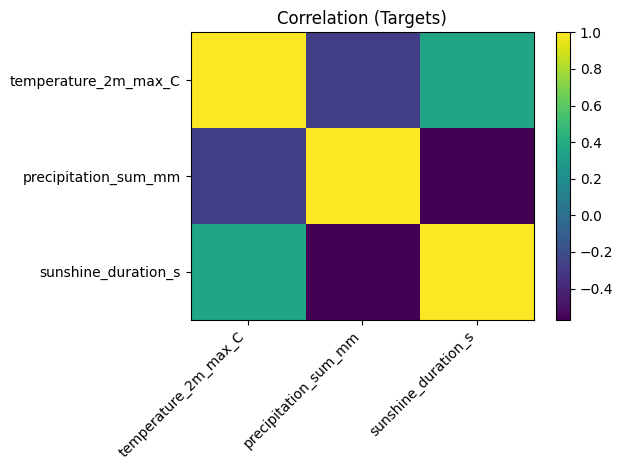

In [51]:
# Simple correlation heatmap among numeric targets (and a few numeric features if exist)
num_cols = df.select_dtypes(include="number").columns.tolist()
corr_cols = [c for c in [TEMP_COL, RAIN_COL, SUN_COL] if c in num_cols]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    plt.figure()
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
    plt.yticks(range(len(corr_cols)), corr_cols)
    plt.title("Correlation (Targets)")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

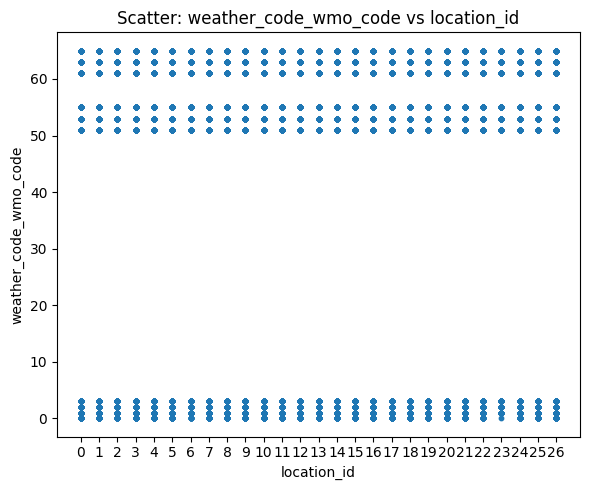

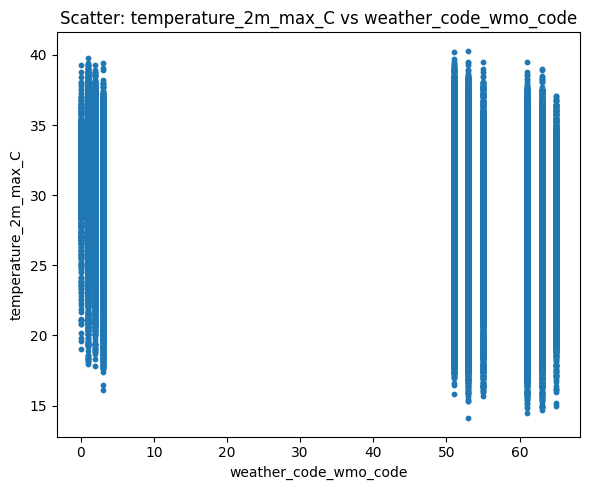

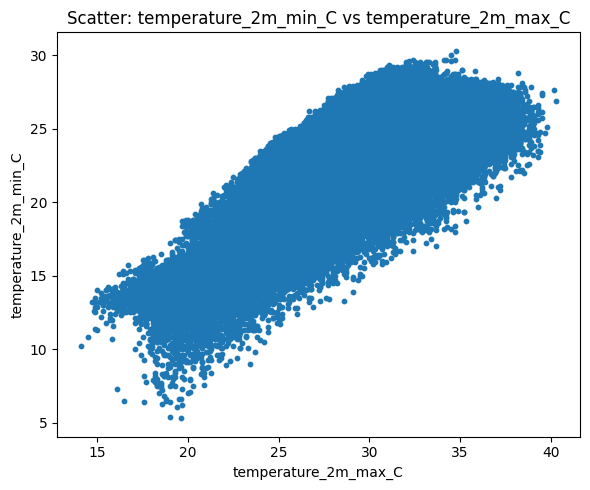

In [52]:
# ---------------------------
# 11) Scatter plots
# ---------------------------
if len(numeric_cols) >= 2:
    # Choose 3 pairs max
    pairs = []
    for i in range(min(3, len(numeric_cols) - 1)):
        pairs.append((numeric_cols[i], numeric_cols[i+1]))

    for x, y in pairs:
        tmp = df[[x, y]].dropna()
        if tmp.empty:
            continue

        plt.figure(figsize=(6, 5))
        plt.scatter(tmp[x], tmp[y], s=10)
        plt.title(f"Scatter: {y} vs {x}")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.tight_layout()
        plt.show()

# **Preprocessing**

In [53]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [54]:
# ---------------------------
# 1) Column name cleaning
# ---------------------------
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w_]", "", regex=True)
)

print("\n Columns:", df.columns.tolist())


 Columns: ['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']


In [55]:
# ---------------------------
# 2) Basic cleaning: duplicates
# ---------------------------
dup_count = df.duplicated().sum()
print("\nDuplicate rows:", dup_count)
if dup_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(" Duplicates removed. New shape:", df.shape)


Duplicate rows: 0


In [56]:
# ---------------------------
# 3) Fix common "missing" strings -> NaN
# ---------------------------
missing_tokens = ["NA", "N/A", "na", "n/a", "null", "NULL", "None", "none", "-", "--", " "]
df = df.replace(missing_tokens, np.nan)

In [57]:
import pandas as pd

# Clean column names (removes hidden spaces)
df.columns = df.columns.astype(str).str.strip()

print("Columns:", df.columns.tolist())

# Auto-detect a date/time column
date_like_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "time", "timestamp", "datetime"])]

DATE_COL = None
best_ratio = 0

for c in date_like_cols:
    parsed = pd.to_datetime(df[c], errors="coerce")
    ratio = parsed.notna().mean()
    if ratio > best_ratio:
        best_ratio = ratio
        DATE_COL = c

if DATE_COL is None or best_ratio < 0.5:
    raise ValueError(f"No reliable date column found. Date-like columns tried: {date_like_cols}")

print("Using date column:", DATE_COL, " (parse success:", round(best_ratio, 2), ")")

Columns: ['location_id', 'date', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'sunrise', 'sunset']
Using date column: date  (parse success: 1.0 )


In [58]:
# ==============================
# 5) PREPROCESSING FOR TRAINING
#    Inputs: date + season + location
# ==============================
# Create time features
df = df.dropna(subset=[DATE_COL, LOC_COL, TEMP_COL, RAIN_COL, SUN_COL]).copy()

df["year"] = df[DATE_COL].dt.year
df["month"] = df[DATE_COL].dt.month
df["day_of_year"] = df[DATE_COL].dt.dayofyear

# If dataset doesn't have "season", create it
if "season" not in df.columns:
    def season_from_month(m):
        # Sri Lanka-friendly rough seasons (you can adjust)
        if m in [3, 4]:
            return "Inter-Monsoon-1"
        if m in [5, 6, 7, 8, 9]:
            return "SW-Monsoon"
        if m in [10, 11]:
            return "Inter-Monsoon-2"
        return "NE-Monsoon"  # Dec, Jan, Feb
    df["season"] = df["month"].apply(season_from_month)
else:
    df["season"] = df["season"].astype(str)

# Sunshine convert to hours if it's in seconds (common case: *_s)
# If SUN_COL already hours, this will still work but won't convert.
SUN_H_COL = "sunshine_h"
if "duration" in SUN_COL.lower() and SUN_COL.lower().endswith("_s"):
    df[SUN_H_COL] = pd.to_numeric(df[SUN_COL], errors="coerce") / 3600.0
else:
    df[SUN_H_COL] = pd.to_numeric(df[SUN_COL], errors="coerce")

# Make targets numeric
df[TEMP_COL] = pd.to_numeric(df[TEMP_COL], errors="coerce")
df[RAIN_COL] = pd.to_numeric(df[RAIN_COL], errors="coerce")

df = df.dropna(subset=[TEMP_COL, RAIN_COL, SUN_H_COL]).copy()

print("\nAfter preprocessing:", df.shape)

# X (inputs) and Y (3 targets)
X = df[[LOC_COL, "season", "month", "day_of_year", "year"]]
Y = df[[TEMP_COL, RAIN_COL, SUN_H_COL]].copy()
Y.columns = ["temperature_C", "rainfall_mm", "sunshine_h"]  # rename cleanly


After preprocessing: (142371, 26)


In [59]:
# ---------------------------
# 6) Convert numeric-like object columns safely
# ---------------------------
def try_convert_numeric(series: pd.Series) -> pd.Series:
    # remove commas in numbers like "1,234"
    s = series.astype(str).str.replace(",", "", regex=False)
    s = s.replace("nan", np.nan)
    converted = pd.to_numeric(s, errors="coerce")
    # If conversion makes many values numeric -> accept conversion
    if converted.notna().mean() >= 0.7:
        return converted
    return series

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = try_convert_numeric(df[col])

print("\n After numeric conversion:")
print(df.dtypes)


 After numeric conversion:
location_id                               int64
date                             datetime64[ns]
weather_code_wmo_code                     int64
temperature_2m_max_C                    float64
temperature_2m_min_C                    float64
temperature_2m_mean_C                   float64
apparent_temperature_max_C              float64
apparent_temperature_min_C              float64
apparent_temperature_mean_C             float64
daylight_duration_s                     float64
sunshine_duration_s                     float64
precipitation_sum_mm                    float64
rain_sum_mm                             float64
precipitation_hours_h                     int64
wind_speed_10m_max_kmh                  float64
wind_gusts_10m_max_kmh                  float64
wind_direction_10m_dominant_              int64
shortwave_radiation_sum_MJm²            float64
et0_fao_evapotranspiration_mm           float64
sunrise                                  object
sunset      

In [60]:
# ---------------------------
# 7) Outlier clipping for numeric columns (IQR method)
#    (Helps some models; you can disable if you want)
# ---------------------------
def iqr_clip(data: pd.DataFrame, numeric_cols: list, k: float = 1.5) -> pd.DataFrame:
    clipped = data.copy()
    for c in numeric_cols:
        if pd.api.types.is_numeric_dtype(clipped[c]):
            q1 = clipped[c].quantile(0.25)
            q3 = clipped[c].quantile(0.75)
            iqr = q3 - q1
            if pd.isna(iqr) or iqr == 0:
                continue
            lower = q1 - k * iqr
            upper = q3 + k * iqr
            clipped[c] = clipped[c].clip(lower, upper)
    return clipped

numeric_cols_now = df.select_dtypes(include=[np.number]).columns.tolist()
df = iqr_clip(df, numeric_cols_now, k=1.5)

In [61]:
X = df.copy()

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)
print("X shape (before preprocessing):", X.shape)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

X_processed = preprocessor.fit_transform(X)
print("X_processed shape:", X_processed.shape)


# ---- Get final feature names (after onehot)
def get_feature_names(preprocessor, num_cols, cat_cols):
    names = []
    names.extend(num_cols)
    if len(cat_cols) > 0:
        ohe = preprocessor.named_transformers_["cat"].named_steps["onehot"]
        names.extend(ohe.get_feature_names_out(cat_cols).tolist())
    return names

final_feature_names = get_feature_names(preprocessor, num_cols, cat_cols)

X_processed_df = pd.DataFrame.sparse.from_spmatrix(
    X_processed,
    columns=final_feature_names
)
print("\n Processed X DataFrame preview:")
print(X_processed_df.head())


Numeric cols: ['location_id', 'weather_code_wmo_code', 'temperature_2m_max_C', 'temperature_2m_min_C', 'temperature_2m_mean_C', 'apparent_temperature_max_C', 'apparent_temperature_min_C', 'apparent_temperature_mean_C', 'daylight_duration_s', 'sunshine_duration_s', 'precipitation_sum_mm', 'rain_sum_mm', 'precipitation_hours_h', 'wind_speed_10m_max_kmh', 'wind_gusts_10m_max_kmh', 'wind_direction_10m_dominant_', 'shortwave_radiation_sum_MJm²', 'et0_fao_evapotranspiration_mm', 'year', 'month', 'day_of_year', 'sunshine_h']
Categorical cols: ['date', 'sunrise', 'sunset', 'season']
X shape (before preprocessing): (142371, 26)
X_processed shape: (142371, 5402)

 Processed X DataFrame preview:
   location_id  weather_code_wmo_code  temperature_2m_max_C  \
0    -1.669046              -1.678989              0.233181   
1    -1.669046              -0.119105              0.233181   
2    -1.669046              -0.119105              0.072367   
3    -1.669046              -1.678989             -0.1

In [62]:
import pandas as pd
import numpy as np
import gc
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

DATE_COL = "date"
LOC_COL = "location_id"
TARGET = "temperature_2m_mean_C"

# Keep only needed columns first
needed_cols = [DATE_COL, LOC_COL, TARGET, "season"]
df_small = df[needed_cols].copy()

# Convert types
df_small[DATE_COL] = pd.to_datetime(df_small[DATE_COL], errors="coerce")
df_small[LOC_COL] = df_small[LOC_COL].astype(str)

# Drop missing rows without extra big operations
mask = (
    df_small[DATE_COL].notna() &
    df_small[LOC_COL].notna() &
    df_small[TARGET].notna()
)
df_small = df_small.loc[mask]

# Date features
df_small["month"] = df_small[DATE_COL].dt.month.astype("int16")
df_small["day_of_year"] = df_small[DATE_COL].dt.dayofyear.astype("int16")
df_small["year"] = df_small[DATE_COL].dt.year.astype("int16")

# If season is missing
if "season" not in df_small.columns or df_small["season"].isna().all():
    def season_from_month(m):
        if m in [3, 4]:
            return "Inter-Monsoon-1"
        if m in [5, 6, 7, 8, 9]:
            return "SW-Monsoon"
        if m in [10, 11]:
            return "Inter-Monsoon-2"
        return "NE-Monsoon"
    df_small["season"] = df_small["month"].apply(season_from_month)

# Final ML data
X = df_small[[LOC_COL, "season", "month", "day_of_year", "year"]]
y = df_small[TARGET].astype("float32")

print(X.shape, y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), [LOC_COL, "season"]),
    ("num", "passthrough", ["month", "day_of_year", "year"])
])

model = Pipeline([
    ("preprocess", preprocess),
    ("rf", RandomForestRegressor(
        n_estimators=30,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=1
    ))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

(142371, 5) (142371,)
MAE: 0.9189992014101586
R²: 0.7643399380374953
RMSE: 1.214906312566155


In [63]:
# ==============================
# 9) SAVE MODEL + METADATA
# ==============================
joblib.dump(model, "rf_weather_3targets.pkl")

metadata = {
    "date_col": DATE_COL,
    "location_col": LOC_COL,
    "features_used": [LOC_COL, "season", "month", "day_of_year", "year"],
    "targets": ["temperature_C", "rainfall_mm", "sunshine_h"],
    "original_target_cols": {
        "temperature": TEMP_COL,
        "rainfall": RAIN_COL,
        "sunshine": SUN_COL
    }
}
joblib.dump(metadata, "rf_weather_3targets_metadata.pkl")

print("\nSaved:")
print("- rf_weather_3targets.pkl")
print("- rf_weather_3targets_metadata.pkl")


Saved:
- rf_weather_3targets.pkl
- rf_weather_3targets_metadata.pkl
